In [207]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score, mean_absolute_percentage_error  
import pickle

### Sistema de predicción de ventas

Queremos establecer el almacén de nuestra empresa en otra localización y necesitamos estimar el ritmo de las ventas, que desde la creación de la empresa ha ido en aumento, para los próximos meses, a fin de proveer el espacio que necesitaremos.

In [208]:
df = pd.read_csv('/workspaces/Antonio27M-machine-learning/data/raw/internal-link-proyecto10.csv')

In [209]:
df.head()

,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633


In [210]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    366 non-null    object 
 1   sales   366 non-null    float64
dtypes: float64(1), object(1)
memory usage: 5.8+ KB


In [211]:
df.dtypes

date      object
sales    float64
dtype: object

In [212]:
df.columns

Index(['date', 'sales'], dtype='object')

In [213]:
df.shape

(366, 2)

In [214]:
df.duplicated().sum()

0

In [215]:
df.nunique()

date     366
sales    366
dtype: int64

In [216]:
df.isna().sum()

date     0
sales    0
dtype: int64

In [217]:
df['date'] = pd.to_datetime(df['date'])

In [218]:
df['date'].min()

Timestamp('2022-09-03 17:10:08.079328')

In [219]:
df['date'].max()

Timestamp('2023-09-03 17:10:08.079328')

In [220]:
df.describe()

,date,sales
count,366,366.000000
mean,2023-03-05 05:10:08.079328,524.963968
min,2022-09-03 17:10:08.079328,53.803211
25%,2022-12-03 23:10:08.079328,290.186822
50%,2023-03-05 05:10:08.079328,520.699468
75%,2023-06-04 11:10:08.079328,763.289263
max,2023-09-03 17:10:08.079328,1000.482785
std,NaN,275.089698


In [221]:
df_time = df.set_index('date')
serie_tiempo = df_time['sales']


### Grafica de serie. 

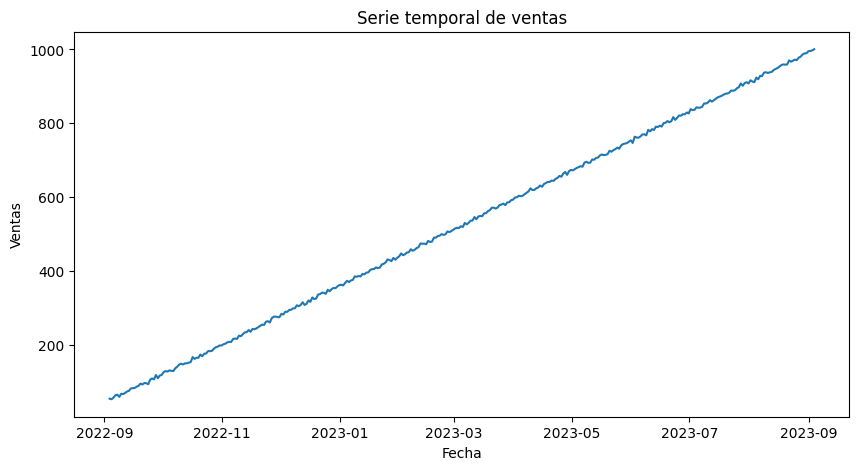

In [222]:
plt.figure(figsize=(10,5))
plt.plot(serie_tiempo)
plt.title("Serie temporal de ventas")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.show()


No es estacionaria, la serie no es lineal y va de manera creciente. El tensor de la serie temporal es diario, ya que los datos están registrados para cada día.

### Grafica de ARIMA: estacionaria. 

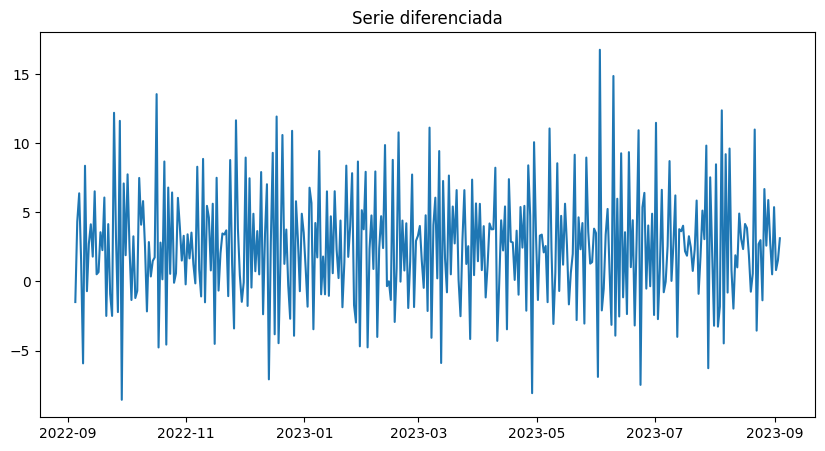

In [223]:
tserie_diff = serie_tiempo.diff().dropna()

plt.figure(figsize=(10,5))
plt.plot(tserie_diff)
plt.title("Serie diferenciada")
plt.show()


### Slipt.

In [224]:
train_size = int(len(serie_tiempo) * 0.8)
train, test = serie_tiempo[:train_size], serie_tiempo[train_size:]


### Modelado.

In [225]:

model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())


/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                  292
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -838.546
Date:                Fri, 13 Feb 2026   AIC                           1683.092
Time:                        13:42:16   BIC                           1694.112
Sample:                    09-03-2022   HQIC                          1687.506
                         - 06-21-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000      0.001   1863.304      0.000       0.999       1.001
ma.L1         -0.9996      0.473     -2.111      0.035      -1.928      -0.072
sigma2        18.3520      8.857      2.072      0.0

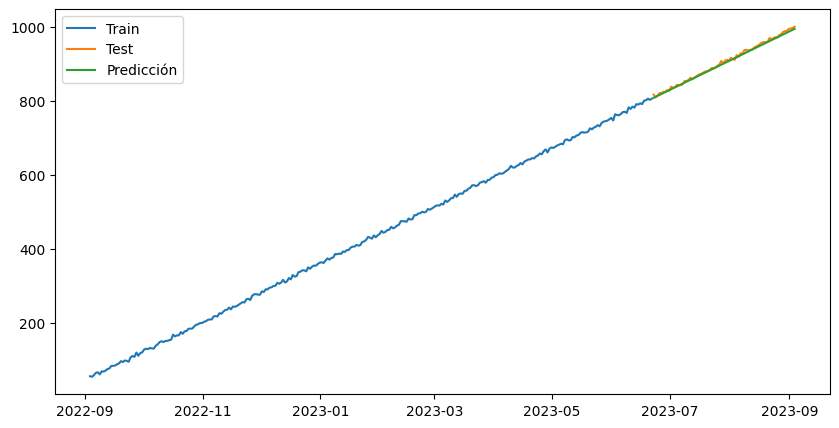

In [226]:
predicciones = model_fit.forecast(steps=len(test))

plt.figure(figsize=(10,5))
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.plot(test.index, predicciones, label="Predicción")
plt.legend()
plt.show()


### Metricas. 

In [227]:
metrics = {'MSE': mean_squared_error(test, predicciones),'RMSE': root_mean_squared_error(test, predicciones),
           'MAPE': mean_absolute_percentage_error(test, predicciones),'R^2': r2_score(test, predicciones), }

metrics

{'MSE': 16.585962311162486,
 'RMSE': 4.0725866855307675,
 'MAPE': 0.003597214370692161,
 'R^2': 0.9946153873113986}

### Conclusion.   

El modelo ARIMA fue evaluado utilizando las métricas MSE, RMSE, MAPE y R². Los resultados muestran un RMSE de 4.07, lo que indica un bajo error promedio en las predicciones. El MAPE es de 0.36 %, lo que refleja una alta precisión del modelo. Además, el coeficiente R² es de 0.9946, lo que significa que el modelo explica el 99.46 % de la variabilidad de la serie temporal. En conclusión, el modelo presenta un rendimiento excelente y es capaz de predecir la serie temporal con alta precisión.

### Guardado del modelo. 

In [228]:
with open("arima_model.pkl", "wb") as f:
    pickle.dump(model_fit, f)